input data shape: torch.Size([768, 8]) target shape: torch.Size([768, 1])
epoch= 500, loss=0.4667, acc=0.7865
epoch=1000, loss=0.4453, acc=0.8021
epoch=1500, loss=0.4223, acc=0.8190
epoch=2000, loss=0.4103, acc=0.8242
epoch=2500, loss=0.4037, acc=0.8216
epoch=3000, loss=0.4004, acc=0.8242
epoch=3500, loss=0.3950, acc=0.8242
epoch=4000, loss=0.3919, acc=0.8242
epoch=4500, loss=0.3889, acc=0.8333
epoch=5000, loss=0.3878, acc=0.8359


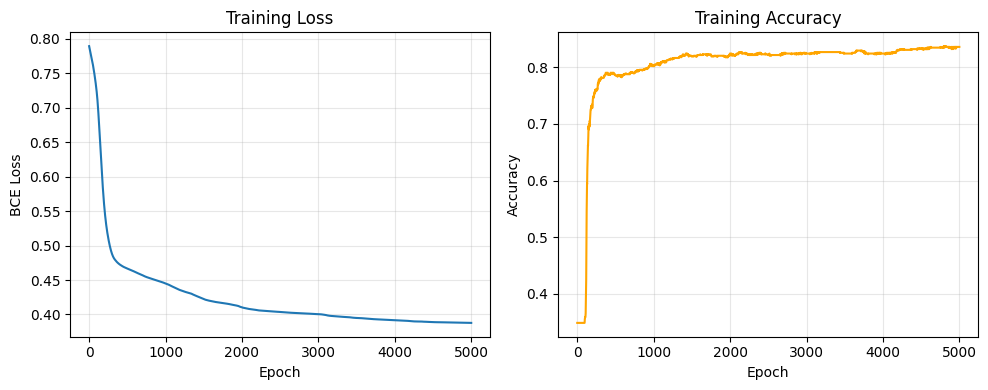

In [ ]:
import os
import urllib.request
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# ------------------------------
# 1) Prepare dataset
# ------------------------------
# 优先读取本地 diabetes.csv；若不存在则自动下载常用 Pima Indians Diabetes 数据集
data_path = "diabetes.csv"
if not os.path.exists(data_path):
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    urllib.request.urlretrieve(url, data_path)
    print(f"Downloaded dataset to: {data_path}")

xy = np.loadtxt(data_path, delimiter=",", dtype=np.float32)    # 读取数据，存储为形状是 (行数, 列数) 的 NumPy 数组，其中每个元素都是 32 位浮点数

# 第一个 ':' 读取所有行；第二个 ':' 读取前 8 列特征；最后一列是标签
x_np = xy[:, :-1]
y_np = xy[:, [-1]]

# 特征标准化：将每列缩放到均值 0、标准差 1
# 不做这一步的话，8 个特征量纲差异极大（glucose~200, pedigree~0-2.5），
# 梯度会被大尺度特征主导，模型几乎学不动
mean = x_np.mean(axis=0)    # 计算每列的均值, axis=0表示按列计算, 即在行的方向上计算均值
std  = x_np.std(axis=0)    # 计算每列的标准差
x_np = (x_np - mean) / (std + 1e-7)    # 对原始数据进行中心化（减去均值）和缩放（除以标准差）, 最终得到的 x_np 中，每个特征的均值变为0，标准差变为1。

x_data = torch.from_numpy(x_np)    # 将 numpy 数组转换为 PyTorch 张量
y_data = torch.from_numpy(y_np)    # 将 numpy 数组转换为 PyTorch 张量
print("input data shape:", x_data.shape, "target shape:", y_data.shape)

# 使用 TensorDataset + DataLoader：按 mini-batch 打乱并迭代（训练时常用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = TensorDataset(x_data, y_data)
batch_size = 64
train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
)

# ------------------------------
# 2) Define model
# ------------------------------
class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = torch.nn.Linear(8, 6)
        self.linear2 = torch.nn.Linear(6, 4)
        self.linear3 = torch.nn.Linear(4, 2)
        self.linear4 = torch.nn.Linear(2, 1)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.relu(self.linear3(x))
        x = self.linear4(x)  # 输出 logits（不加 sigmoid）
        return x

model = Model().to(device)

# ------------------------------
# 3) Loss + optimizer
# ------------------------------
# 用 BCEWithLogitsLoss 更稳定（内部自带 sigmoid）
criterion = torch.nn.BCEWithLogitsLoss(reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ------------------------------
# 4) Training
# ------------------------------
num_epochs = 5000
loss_history = []
acc_history = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_correct = 0
    n_samples = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            pred_label = (logits >= 0).float()
            epoch_correct += (pred_label == batch_y).float().sum().item()
        epoch_loss += loss.item() * batch_x.size(0)
        n_samples += batch_y.size(0)

    loss_history.append(epoch_loss / n_samples)
    acc_history.append(epoch_correct / n_samples)

    if (epoch + 1) % 500 == 0:
        print(f"epoch={epoch+1:4d}, loss={loss.item():.4f}, acc={acc:.4f}")

# ------------------------------
# 5) Visualization
# ------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(acc_history, label="Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()